In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers,models,optimizers,regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
train_gen = ImageDataGenerator(rescale=1/255.0)

test_gen = ImageDataGenerator(rescale=1/255.0)

In [3]:
trainImageData = train_gen.flow_from_directory("cats_and_dogs/train",
                                                batch_size=32,
                                                class_mode="binary",
                                                target_size=(128,128))

testImageData = test_gen.flow_from_directory("cats_and_dogs/validation/",
                                                    batch_size=32,
                                                    class_mode="binary",
                                                    target_size=(128,128))

Found 1600 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


In [4]:
trainImageData.class_indices

{'cats': 0, 'dogs': 1}

In [5]:
trainImageData.image_shape

(128, 128, 3)

In [9]:
model = tf.keras.models.Sequential()

# convolution layers

model.add(layers.Conv2D(32, (3,3), padding='same', input_shape = trainImageData.image_shape, activation='relu'))
model.add(layers.MaxPool2D(pool_size=(2,2)))

model.add(layers.Conv2D(16, (3,3), padding='same', activation='relu'))
model.add(layers.MaxPool2D(pool_size=(2,2)))

model.add(layers.Flatten())

model.add(layers.Dense(1024,activation='relu'))
model.add(layers.Dropout(0.25))

model.add(layers.Dense(512,activation='relu'))
model.add(layers.Dropout(0.2))

model.add(layers.Dense(256,activation='relu'))

model.add(layers.Dense(1,activation='sigmoid'))

In [10]:
model.compile(loss='binary_crossentropy',optimizer='ADAM',metrics=['accuracy'])

In [11]:
model.fit(trainImageData,validation_data=testImageData,epochs=20)

Epoch 1/20
50/50 [==============================] - 45s 905ms/step - loss: 1.0031 - accuracy: 0.5188 - val_loss: 0.6891 - val_accuracy: 0.5550
Epoch 2/20
50/50 [==============================] - 45s 890ms/step - loss: 0.6838 - accuracy: 0.5775 - val_loss: 0.6774 - val_accuracy: 0.5650
Epoch 3/20
50/50 [==============================] - 44s 888ms/step - loss: 0.6204 - accuracy: 0.6569 - val_loss: 0.6501 - val_accuracy: 0.6310
Epoch 4/20
50/50 [==============================] - 46s 929ms/step - loss: 0.5104 - accuracy: 0.7575 - val_loss: 0.7121 - val_accuracy: 0.6210
Epoch 5/20
50/50 [==============================] - 50s 991ms/step - loss: 0.3732 - accuracy: 0.8363 - val_loss: 0.9896 - val_accuracy: 0.6180
Epoch 6/20
50/50 [==============================] - 48s 962ms/step - loss: 0.2218 - accuracy: 0.9081 - val_loss: 1.2252 - val_accuracy: 0.6200
Epoch 7/20
50/50 [==============================] - 46s 930ms/step - loss: 0.1060 - accuracy: 0.9594 - val_loss: 1.3182 - val_accuracy: 0.5890

In [12]:
model.evaluate(testImageData)

32/32 [==============================] - 7s 203ms/step - loss: 3.8022 - accuracy: 0.6120


[3.8022048473358154, 0.6119999885559082]

In [22]:
img  = tf.keras.preprocessing.image.load_img("cat.170.jpg",target_size=(128,128))

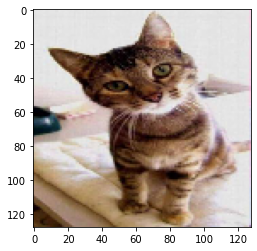

In [23]:
plt.imshow(img)

In [19]:
imgArray = tf.keras.preprocessing.image.img_to_array(img)

In [25]:
img = tf.keras.preprocessing.image.load_img('dog.jpg',target_size=(128,128))

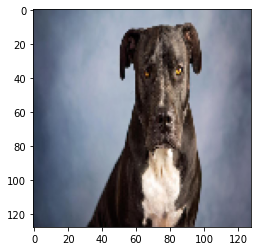

In [26]:
plt.imshow(img)

In [27]:
imgArray = tf.keras.preprocessing.image.img_to_array(img)

In [30]:
imgArrayComp=np.expand_dims(imgArray,axis=0)


In [31]:
model.predict(imgArrayComp)

array([[1.]], dtype=float32)